In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



# Load the dataset, explicitly stating no header in the file
df = pd.read_csv('/content/Medical-Insurance.csv', header=None)

# Assign correct column names based on domain knowledge and data inspection
df.columns = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

print("DataFrame head after renaming columns:")
print(df.head())
print("\nDataFrame info after renaming columns:")
df.info()

# Replace '?' in 'smoker' column with NaN
df['smoker'] = df['smoker'].replace('?', np.nan)

# Convert 'age' to numeric, coercing errors to NaN
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Convert 'smoker' to numeric, coercing errors to NaN (after handling '?')
df['smoker'] = pd.to_numeric(df['smoker'], errors='coerce')

# Check for missing values again after handling '?' and type conversion
print("\nMissing values per column after cleaning 'smoker' column and type conversion:")
print(df.isnull().sum())

# Display value counts for 'smoker' column to show NaN
print("\n'smoker' column value counts (including NaN) after type conversion:")
print(df['smoker'].value_counts(dropna=False))

print("\nDataFrame info after type conversions:")
df.info()

DataFrame head after renaming columns:
  age  sex     bmi  children smoker  region      charges
0  19    1  27.900         0      1       3  16884.92400
1  18    2  33.770         1      0       4   1725.55230
2  28    2  33.000         3      0       4   4449.46200
3  33    2  22.705         0      0       1  21984.47061
4  32    2  28.880         0      0       1   3866.85520

DataFrame info after renaming columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   object 
 1   sex       2772 non-null   int64  
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   int64  
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB

Missing values per column after cleaning 'smoker' column 

In [2]:
# Impute missing values for 'age' with the mean
df['age'] = df['age'].fillna(df['age'].mean())

# Impute missing values for 'smoker' with the mode
df['smoker'] = df['smoker'].fillna(df['smoker'].mode()[0])

# Convert 'sex' and 'region' to categorical data types
df['sex'] = df['sex'].astype('category')
df['region'] = df['region'].astype('category')

print("\nMissing values per column after imputation:")
print(df.isnull().sum())

print("\nDataFrame info after imputation and categorical conversion:")
df.info()


Missing values per column after imputation:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

DataFrame info after imputation and categorical conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       2772 non-null   float64 
 1   sex       2772 non-null   category
 2   bmi       2772 non-null   float64 
 3   children  2772 non-null   int64   
 4   smoker    2772 non-null   float64 
 5   region    2772 non-null   category
 6   charges   2772 non-null   float64 
dtypes: category(2), float64(4), int64(1)
memory usage: 114.1 KB


In [3]:
# Identify numerical columns for scaling (excluding 'charges' which is the target and categorical columns)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Remove 'charges' from the numerical columns to be scaled
if 'charges' in numerical_cols:
    numerical_cols.remove('charges')

print(f"Numerical columns to be scaled: {numerical_cols}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("\nDataFrame head after feature scaling:")
print(df.head())

print("\nDataFrame info after feature scaling:")
df.info()

Numerical columns to be scaled: ['age', 'bmi', 'children', 'smoker']

DataFrame head after feature scaling:
        age sex       bmi  children    smoker region      charges
0 -1.428364   1 -0.457114 -0.907084  1.978609      3  16884.92400
1 -1.499393   2  0.500731 -0.083758 -0.505406      4   1725.55230
2 -0.789111   2  0.375085  1.562893 -0.505406      4   4449.46200
3 -0.433970   2 -1.304814 -0.907084 -0.505406      1  21984.47061
4 -0.504998   2 -0.297201 -0.907084 -0.505406      1   3866.85520

DataFrame info after feature scaling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       2772 non-null   float64 
 1   sex       2772 non-null   category
 2   bmi       2772 non-null   float64 
 3   children  2772 non-null   float64 
 4   smoker    2772 non-null   float64 
 5   region    2772 non-null   category
 6   charges   2772 non-null   

In [4]:
# For correlation matrix, we need to handle categorical variables first.
# Convert 'sex' and 'region' categorical columns into numerical using one-hot encoding.
# Make a copy to avoid modifying the original df for now if not intended.
df_encoded = pd.get_dummies(df, columns=['sex', 'region'], drop_first=True)

print("DataFrame head after one-hot encoding categorical features:")
print(df_encoded.head())
print("\nDataFrame info after one-hot encoding:")
df_encoded.info()

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Get the correlation with the target variable 'charges'
charges_correlation = correlation_matrix['charges'].sort_values(ascending=False)

# Exclude 'charges' itself and display the top 5 most correlated features
top_5_correlated_features = charges_correlation[1:6] # Exclude 'charges' itself (index 0)

print("\nTop 5 features most correlated with 'charges':")
print(top_5_correlated_features)

DataFrame head after one-hot encoding categorical features:
        age       bmi  children    smoker      charges  sex_2  region_2  \
0 -1.428364 -0.457114 -0.907084  1.978609  16884.92400  False     False   
1 -1.499393  0.500731 -0.083758 -0.505406   1725.55230   True     False   
2 -0.789111  0.375085  1.562893 -0.505406   4449.46200   True     False   
3 -0.433970 -1.304814 -0.907084 -0.505406  21984.47061   True     False   
4 -0.504998 -0.297201 -0.907084 -0.505406   3866.85520   True     False   

   region_3  region_4  
0      True     False  
1     False      True  
2     False      True  
3     False     False  
4     False     False  

DataFrame info after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   float64
 1   bmi       2772 non-null   float64
 2   children  2772 non-null   float64
 3  

In [5]:
# Create a binary target variable based on the median of 'charges'
median_charges = df_encoded['charges'].median()
df_encoded['is_high_charge'] = (df_encoded['charges'] > median_charges).astype(int)

# Define features (X) and target (y)
X = df_encoded.drop(columns=['charges', 'is_high_charge'])
y = df_encoded['is_high_charge']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of target variable in training set:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of target variable in test set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (2217, 8)
Shape of X_test: (555, 8)
Shape of y_train: (2217,)
Shape of y_test: (555,)

Distribution of target variable in training set:
is_high_charge
1    0.500226
0    0.499774
Name: proportion, dtype: float64

Distribution of target variable in test set:
is_high_charge
0    0.500901
1    0.499099
Name: proportion, dtype: float64


### **Logistic Regression (Baseline)**

In [6]:
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Precision: {precision_lr:.4f}")
print(f"Logistic Regression Recall: {recall_lr:.4f}")

Logistic Regression Accuracy: 0.9243
Logistic Regression Precision: 0.9211
Logistic Regression Recall: 0.9278


### **Random Forest Classifier (Ensemble method)**

In [7]:
# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")

Random Forest Accuracy: 0.9910
Random Forest Precision: 1.0000
Random Forest Recall: 0.9819


### **Support Vector Machine (SVM)**

In [8]:
# Initialize and train Support Vector Machine (SVM) model
# Using a linear kernel for simplicity and faster computation, can be adjusted if needed
svm_model = SVC(random_state=42, kernel='linear')
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {accuracy_svm:.4f}")
print(f"SVM Precision: {precision_svm:.4f}")
print(f"SVM Recall: {recall_svm:.4f}")

SVM Accuracy: 0.9243
SVM Precision: 0.9242
SVM Recall: 0.9242


### **Phase C: Visualization**

#### **Comparing Model Performance**

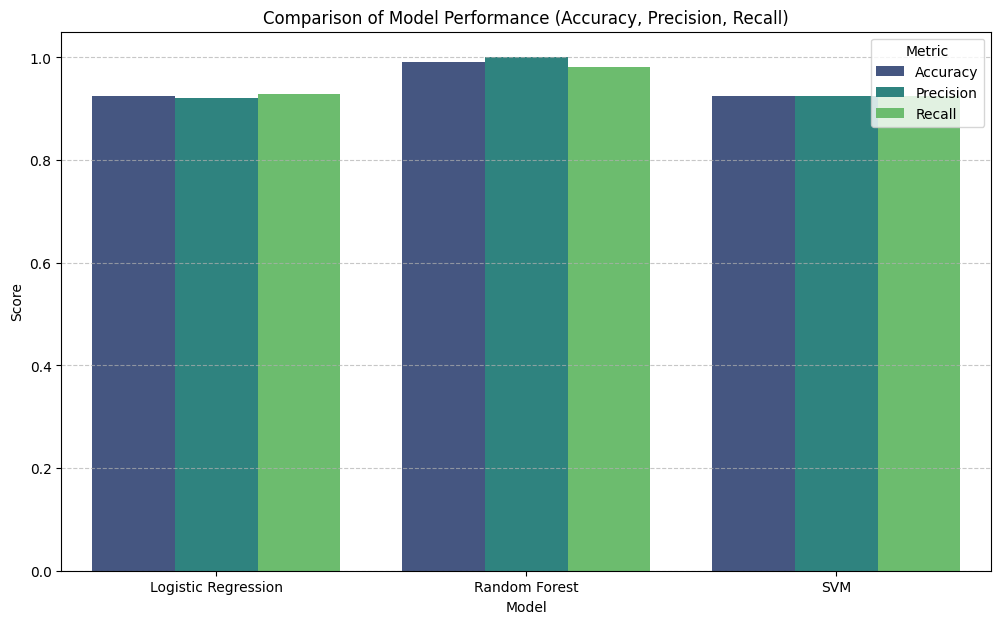

In [9]:


# Create a DataFrame to hold the evaluation metrics
metrics_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_svm],
    'Precision': [precision_lr, precision_rf, precision_svm],
    'Recall': [recall_lr, recall_rf, recall_svm]
}

metrics_df = pd.DataFrame(metrics_data)

# Melt the DataFrame for easier plotting with seaborn
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted, palette='viridis')
plt.title('Comparison of Model Performance (Accuracy, Precision, Recall)')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Set y-axis limit from 0 to 1.05 for better comparison
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Confusion Matrix for Random Forest (Best Performing Model)**

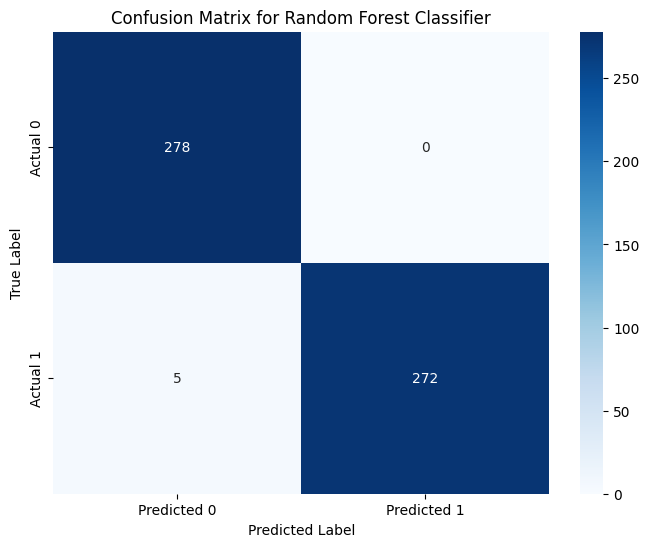

In [10]:
# Generate the confusion matrix for the Random Forest model
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### **Phase C: Visualization**

#### **Comparing Model Performance**

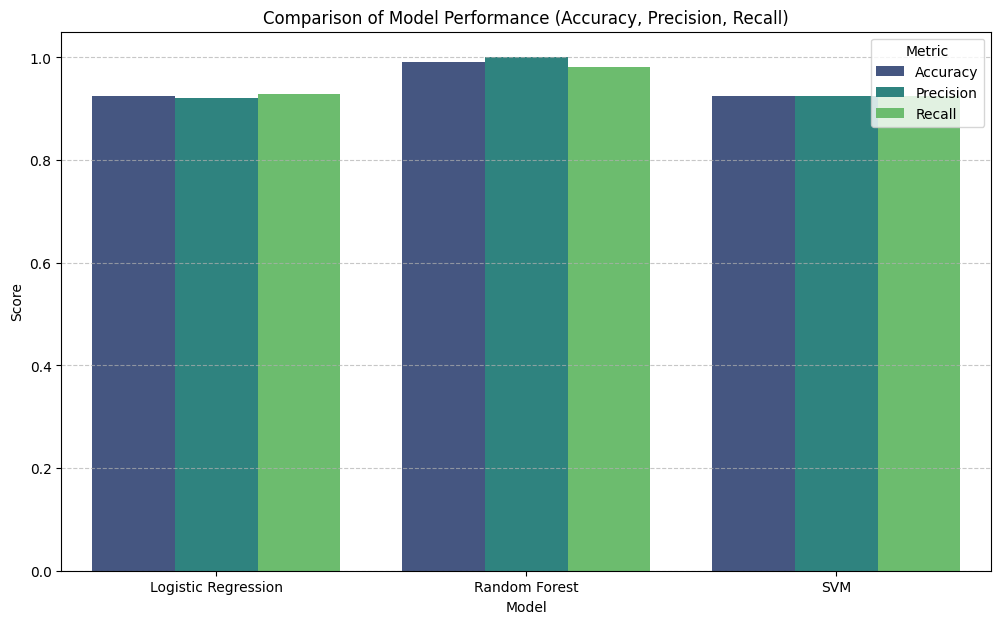

In [11]:
# Create a DataFrame to hold the evaluation metrics
metrics_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_svm],
    'Precision': [precision_lr, precision_rf, precision_svm],
    'Recall': [recall_lr, recall_rf, recall_svm]
}

metrics_df = pd.DataFrame(metrics_data)

# Melt the DataFrame for easier plotting with seaborn
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted, palette='viridis')
plt.title('Comparison of Model Performance (Accuracy, Precision, Recall)')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Set y-axis limit from 0 to 1.05 for better comparison
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Confusion Matrix for Random Forest (Best Performing Model)**

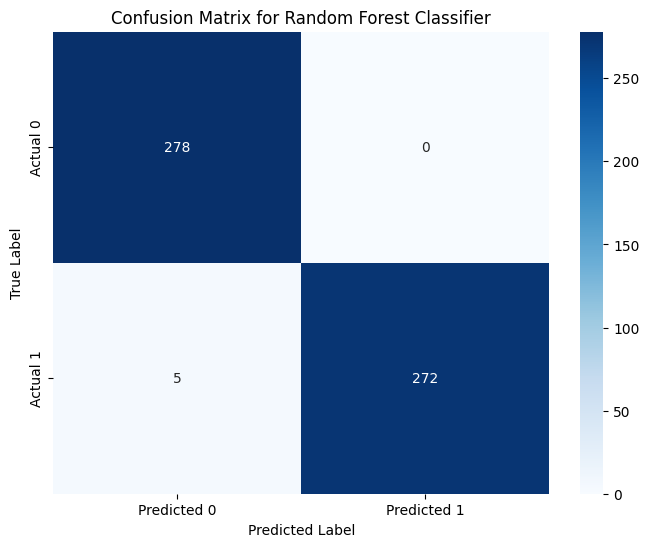

In [12]:
# Generate the confusion matrix for the Random Forest model
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()